# 3500K RVS: Jorg ExoMol vs Korg

This notebook demonstrates, in the **RVS band (8450-8700 A)**, the impact of adding an ExoMol molecular line list to Jorg and compares the result against Korg.jl.

Comparison set:
- Jorg + VALD (no ExoMol)
- Jorg + VALD + ExoMol(CaH)
- Korg + VALD (no ExoMol)
- Korg + VALD + ExoMol(CaH)

Model setup for this example:
- `Teff = 3500 K`
- `logg = 5.0`
- `[M/H] = 0.0`
- `Ca = +1.0` (enhanced to make molecular differences easier to inspect)


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# Paths and runtime options
ROOT = Path('/Users/jdli/Project/jorg/jorg')
KORG_PROJECT = Path('/Users/jdli/Project/jorg/Korg.jl-1.0.1')
EXOMOL_DIR = ROOT / 'data' / 'linelists' / 'exomol' / 'CaH'
STATES_FILE = EXOMOL_DIR / '40Ca-1H__XAB.states'
TRANS_FILE = EXOMOL_DIR / '40Ca-1H__XAB.trans'

OUT_DIR = ROOT / 'output' / 'jupyter-notebook' / 'data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

JORG_CACHE = OUT_DIR / 'jorg_rvs_3500k_cah.npz'
KORG_VALD_CSV = OUT_DIR / 'korg_rvs_3500k_vald.csv'
KORG_EXO_CSV = OUT_DIR / 'korg_rvs_3500k_vald_exomol.csv'

FORCE_RECOMPUTE = False

if not STATES_FILE.exists() or not TRANS_FILE.exists():
    raise FileNotFoundError(
        'ExoMol files not found. Expected:\n'
        f'  {STATES_FILE}\n'
        f'  {TRANS_FILE}\n\n'
        'Download from ExoMol CaH/XAB into this folder before running this notebook.'
    )

print('ROOT:', ROOT)
print('ExoMol states:', STATES_FILE)
print('ExoMol trans:', TRANS_FILE)
print('Output data dir:', OUT_DIR)


ROOT: /Users/jdli/Project/jorg/jorg
ExoMol states: /Users/jdli/Project/jorg/jorg/data/linelists/exomol/CaH/40Ca-1H__XAB.states
ExoMol trans: /Users/jdli/Project/jorg/jorg/data/linelists/exomol/CaH/40Ca-1H__XAB.trans
Output data dir: /Users/jdli/Project/jorg/jorg/output/jupyter-notebook/data


In [3]:
# Jorg imports
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from jorg.synthesis import synth
from jorg.lines import load_exomol_linelist
from jorg.lines.linelist_data import get_VALD_solar_linelist
from jorg.lines.linelist_utils import merge_linelists


In [4]:
# Model parameters
TEFF = 3500.0
LOGG = 5.0
M_H = 0.0
CA_H = 1.0
WL_BOUNDS = (8450.0, 8700.0)
EXOMOL_STRENGTH_CUTOFF = -20.0

print(
    {
        'Teff': TEFF,
        'logg': LOGG,
        'M_H': M_H,
        'Ca': CA_H,
        'wavelengths_A': WL_BOUNDS,
        'exomol_line_strength_cutoff': EXOMOL_STRENGTH_CUTOFF,
    }
)


{'Teff': 3500.0, 'logg': 5.0, 'M_H': 0.0, 'Ca': 1.0, 'wavelengths_A': (8450.0, 8700.0), 'exomol_line_strength_cutoff': -20.0}


In [5]:
# Build Jorg line lists
vald = get_VALD_solar_linelist()
exo = load_exomol_linelist(
    '40Ca-1H',
    STATES_FILE,
    TRANS_FILE,
    lower_wavelength=WL_BOUNDS[0],
    upper_wavelength=WL_BOUNDS[1],
    line_strength_cutoff=EXOMOL_STRENGTH_CUTOFF,
    verbose=False,
)

jorg_combo = merge_linelists([vald, exo], remove_duplicates=False)

print('VALD lines:', len(vald))
print('ExoMol(CaH) lines in RVS window:', len(exo))
print('Merged lines:', len(jorg_combo))


📖 Reading linelist: vald_extract_stellar_solar_threshold001.vald
   Format: vald
   Wavelength unit: auto
   Detected vacuum wavelengths - no conversion needed
   Found 41880 data lines
   Successfully parsed 41861 lines
   After Korg.jl filtering: 41861 lines (removed 0 lines)
VALD lines: 41861
ExoMol(CaH) lines in RVS window: 2533
Merged lines: 44394


In [6]:
# Run Jorg synth (with caching because first JAX compile can be slow)
if JORG_CACHE.exists() and not FORCE_RECOMPUTE:
    jdata = np.load(JORG_CACHE)
    wl_j = jdata['wl_j']
    flux_j_vald = jdata['flux_j_vald']
    flux_j_exo = jdata['flux_j_exo']
    print('Loaded Jorg cache:', JORG_CACHE)
else:
    wl_j, flux_j_vald, _ = synth(
        TEFF,
        LOGG,
        M_H,
        wavelengths=WL_BOUNDS,
        linelist=vald,
        rectify=True,
        verbose=False,
        Ca=CA_H,
    )

    wl_j_exo, flux_j_exo, _ = synth(
        TEFF,
        LOGG,
        M_H,
        wavelengths=WL_BOUNDS,
        linelist=jorg_combo,
        rectify=True,
        verbose=False,
        Ca=CA_H,
    )

    if not np.allclose(wl_j, wl_j_exo):
        raise RuntimeError('Jorg wavelength grids differ between runs; expected same grid.')

    np.savez(JORG_CACHE, wl_j=wl_j, flux_j_vald=flux_j_vald, flux_j_exo=flux_j_exo)
    print('Wrote Jorg cache:', JORG_CACHE)

jorg_exo_delta = flux_j_exo - flux_j_vald
print('Jorg points:', wl_j.size)
print('Jorg ExoMol delta max|f_exo - f_vald| =', float(np.max(np.abs(jorg_exo_delta))))
print('Jorg ExoMol delta mean|.| =', float(np.mean(np.abs(jorg_exo_delta))))


Loaded Jorg cache: /Users/jdli/Project/jorg/jorg/output/jupyter-notebook/data/jorg_rvs_3500k_cah.npz
Jorg points: 25001
Jorg ExoMol delta max|f_exo - f_vald| = 0.16683326674221677
Jorg ExoMol delta mean|.| = 0.01279742257635033


In [7]:
# Run Korg.jl synth through Julia and save CSV outputs (cached)
if (not KORG_VALD_CSV.exists() or not KORG_EXO_CSV.exists()) or FORCE_RECOMPUTE:
    julia_script = f'''
using Pkg
using DelimitedFiles
Pkg.activate("{KORG_PROJECT}")
using Korg

states = "{STATES_FILE}"
trans = "{TRANS_FILE}"

vald = Korg.get_VALD_solar_linelist()
exo = Korg.load_ExoMol_linelist(
    "CaH",
    states,
    trans,
    {WL_BOUNDS[0]},
    {WL_BOUNDS[1]};
    line_strength_cutoff={EXOMOL_STRENGTH_CUTOFF},
    verbose=false,
)
combo = sort([vald; exo], by=l->l.wl)

w0, f0, c0 = Korg.synth(; Teff={TEFF}, logg={LOGG}, M_H={M_H}, Ca={CA_H}, wavelengths=({WL_BOUNDS[0]}, {WL_BOUNDS[1]}), linelist=vald)
w1, f1, c1 = Korg.synth(; Teff={TEFF}, logg={LOGG}, M_H={M_H}, Ca={CA_H}, wavelengths=({WL_BOUNDS[0]}, {WL_BOUNDS[1]}), linelist=combo)

writedlm("{KORG_VALD_CSV}", hcat(w0, f0), ',')
writedlm("{KORG_EXO_CSV}", hcat(w1, f1), ',')
println("Korg CSV written")
'''
    subprocess.run(['julia', '-e', julia_script], check=True)
else:
    print('Loaded cached Korg CSV files')

korg_vald = np.loadtxt(KORG_VALD_CSV, delimiter=',')
korg_exo = np.loadtxt(KORG_EXO_CSV, delimiter=',')

wl_k_vald, flux_k_vald = korg_vald[:, 0], korg_vald[:, 1]
wl_k_exo, flux_k_exo = korg_exo[:, 0], korg_exo[:, 1]

# Interpolate Korg onto Jorg wavelength grid for direct model-to-model comparisons.
flux_k_vald_i = np.interp(wl_j, wl_k_vald, flux_k_vald)
flux_k_exo_i = np.interp(wl_j, wl_k_exo, flux_k_exo)

korg_exo_delta = flux_k_exo_i - flux_k_vald_i
print('Korg points (VALD):', wl_k_vald.size)
print('Korg points (VALD+ExoMol):', wl_k_exo.size)
print('Korg ExoMol delta max|f_exo - f_vald| =', float(np.max(np.abs(korg_exo_delta))))
print('Korg ExoMol delta mean|.| =', float(np.mean(np.abs(korg_exo_delta))))


Loaded cached Korg CSV files
Korg points (VALD): 25001
Korg points (VALD+ExoMol): 25001
Korg ExoMol delta max|f_exo - f_vald| = 0.07863387472843109
Korg ExoMol delta mean|.| = 0.005362177139884321


In [8]:
# Summary statistics table
summary = pd.DataFrame(
    [
        {
            'metric': 'ExoMol impact in Jorg',
            'max_abs': float(np.max(np.abs(jorg_exo_delta))),
            'mean_abs': float(np.mean(np.abs(jorg_exo_delta))),
        },
        {
            'metric': 'ExoMol impact in Korg',
            'max_abs': float(np.max(np.abs(korg_exo_delta))),
            'mean_abs': float(np.mean(np.abs(korg_exo_delta))),
        },
        {
            'metric': 'Jorg vs Korg (VALD only)',
            'max_abs': float(np.max(np.abs(flux_j_vald - flux_k_vald_i))),
            'mean_abs': float(np.mean(np.abs(flux_j_vald - flux_k_vald_i))),
        },
        {
            'metric': 'Jorg vs Korg (VALD + ExoMol)',
            'max_abs': float(np.max(np.abs(flux_j_exo - flux_k_exo_i))),
            'mean_abs': float(np.mean(np.abs(flux_j_exo - flux_k_exo_i))),
        },
    ]
)
summary


,metric,max_abs,mean_abs
0,ExoMol impact in Jorg,0.166833,0.012797
1,ExoMol impact in Korg,0.078634,0.005362
2,Jorg vs Korg (VALD only),0.300442,0.003593
3,Jorg vs Korg (VALD + ExoMol),0.283858,0.008513


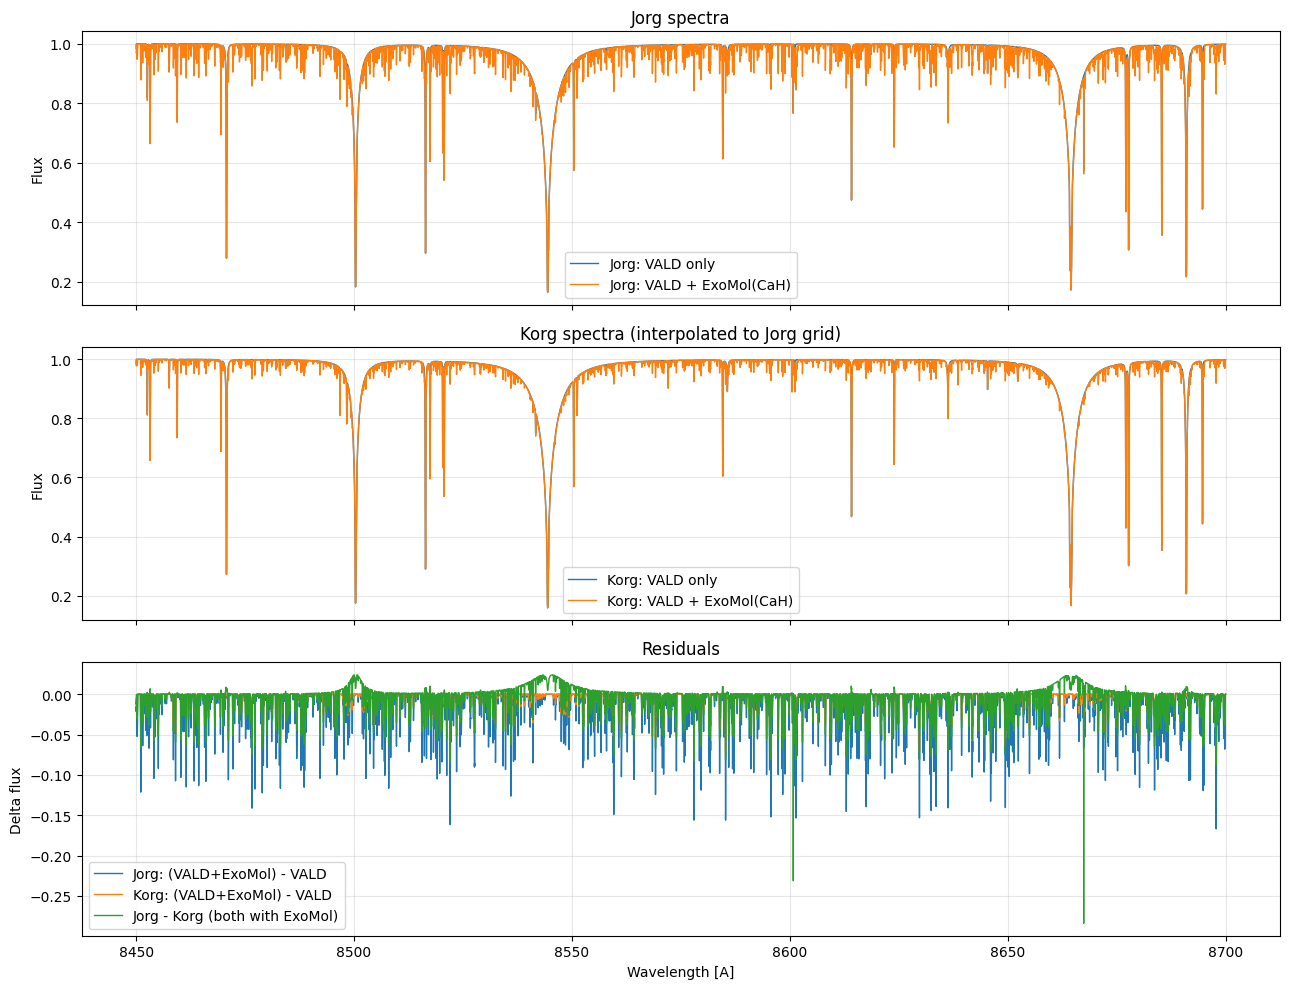

In [9]:
# Plot: with/without ExoMol in each model, plus residuals
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(wl_j, flux_j_vald, lw=1.0, label='Jorg: VALD only')
axes[0].plot(wl_j, flux_j_exo, lw=1.0, label='Jorg: VALD + ExoMol(CaH)')
axes[0].set_ylabel('Flux')
axes[0].set_title('Jorg spectra')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)

axes[1].plot(wl_j, flux_k_vald_i, lw=1.0, label='Korg: VALD only')
axes[1].plot(wl_j, flux_k_exo_i, lw=1.0, label='Korg: VALD + ExoMol(CaH)')
axes[1].set_ylabel('Flux')
axes[1].set_title('Korg spectra (interpolated to Jorg grid)')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

axes[2].plot(wl_j, jorg_exo_delta, lw=1.0, label='Jorg: (VALD+ExoMol) - VALD')
axes[2].plot(wl_j, korg_exo_delta, lw=1.0, label='Korg: (VALD+ExoMol) - VALD')
axes[2].plot(wl_j, flux_j_exo - flux_k_exo_i, lw=1.0, label='Jorg - Korg (both with ExoMol)')
axes[2].set_xlabel('Wavelength [A]')
axes[2].set_ylabel('Delta flux')
axes[2].set_title('Residuals')
axes[2].legend(loc='best')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Notes

- The ExoMol loader added in Jorg for this workflow is `load_exomol_linelist(...)`.
- This notebook uses `line_strength_cutoff = -20` for CaH to make the ExoMol contribution in the RVS window visibly larger.
- First execution is slower due to JAX (Jorg) and Julia (Korg) compilation; cached files under `output/jupyter-notebook/data/` avoid rerunning heavy steps.
